In [1]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torchsummary import summary
from torch.utils.data import TensorDataset, Dataset, DataLoader
!pip install torchview
from torchview import draw_graph
!pip install rangerlite
from rangerlite import RangerLite
!pip install pytorch-optimizer
from pytorch_optimizer import Ranger
import timm


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image, ImageOps
import matplotlib.gridspec as gridspec
import requests
import re
from io import BytesIO
import torch.optim as optim
from collections import defaultdict
import gc
from torchvision.models import ResNet18_Weights

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.6.0+cu124
Device: cuda


# Data Loading

## Patches definition

In [2]:
def sample_centers_from_mask(mask, n, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return []
    idx = rng.integers(0, len(xs), size=n)
    return list(zip(xs[idx], ys[idx]))

def crop_patch(arr, cx, cy, patch):
    H, W = arr.shape[:2]
    x0 = int(np.clip(cx - patch//2, 0, W - patch))
    y0 = int(np.clip(cy - patch//2, 0, H - patch))
    return arr[y0:y0+patch, x0:x0+patch]

def extract_patches_maskaware(img, mask, patch=96, n_patches=6,
                             fallback="random", min_mask_frac=0.01,
                             max_tries=50, rng=None):
    """
    Estrae patch guidate dalla maschera (mask>0).
    - fallback: "random" oppure "tissue" (se implementi tissue mask) oppure "center"
    - min_mask_frac: patch accettata solo se contiene un minimo di mask
    """
    if rng is None:
        rng = np.random.default_rng()

    H, W = mask.shape

    if H == patch and W == patch:
        return [(img, mask)]
    
    patches = []
    tries = 0

    while len(patches) < n_patches and tries < max_tries:
        tries += 1

        centers = sample_centers_from_mask(mask, 1, rng=rng)

        if centers:
            cx, cy = centers[0]
        else:
            # fallback se mask vuota
            if fallback == "center":
                cx, cy = W//2, H//2
            else:
                cx = int(rng.integers(0, W))
                cy = int(rng.integers(0, H))

        ip = crop_patch(img,  cx, cy, patch)
        mp = crop_patch(mask, cx, cy, patch)

        # accetta solo se la patch contiene un minimo di mask (quando la mask non è vuota)
        if mask.sum() > 0 and mp.mean() < min_mask_frac:
            continue

        patches.append((ip, mp))

    # se non trovi patch valide, fai fallback
    if not patches:
        cx = int(rng.integers(0, W))
        cy = int(rng.integers(0, H))
        patches.append((crop_patch(img, cx, cy, patch), crop_patch(mask, cx, cy, patch)))

    return patches

# Images definition

In [3]:
def get_bbox(mask):
    ys, xs = np.where(mask > 0)
    if xs.size == 0:
        return None
    return xs.min(), ys.min(), xs.max() + 1, ys.max() + 1

def extract_crop_from_mask(arr, mask, min_size=96):
    bbox = get_bbox(mask)
    if bbox is None:
        return arr  # niente crop
    x0, y0, x1, y1 = bbox
    # se bbox troppo piccola -> niente crop
    if (x1 - x0) < min_size or (y1 - y0) < min_size:
        return arr
    return arr[y0:y1, x0:x1]

def pad_to_min_size(arr, min_size=96):
    H, W = arr.shape[:2]
    if H >= min_size and W >= min_size:
        return arr

    dh = max(0, min_size - H)
    dw = max(0, min_size - W)

    top = dh // 2
    bottom = dh - top
    left = dw // 2
    right = dw - left

    return cv2.copyMakeBorder(
        arr, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=0
    )

def load_images_from_folder(folder):
    imgs, masks, file_names = [], [], []
    filenames = sorted([f for f in os.listdir(folder)
                        if f.startswith("img") and f.endswith(".png")])

    for filename in filenames:
        img = cv2.imread(os.path.join(folder, filename))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # mucus filter
        hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
        lower = np.array([35, 80, 160], dtype=np.uint8)
        upper = np.array([60, 255, 255], dtype=np.uint8)
        M_art = cv2.inRange(hsv, lower, upper)
        if np.mean(M_art > 0) >= 0.01:
            continue

        mask_name = filename.replace("img", "mask")
        mask = cv2.imread(os.path.join(folder, mask_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            continue
        mask = (mask > 0).astype(np.uint8)

        # crop su bbox mask (ma solo se bbox non è ridicola)
        img_crop  = extract_crop_from_mask(img,  mask, min_size=96)
        mask_crop = extract_crop_from_mask(mask, mask, min_size=96)

        # padding se il crop è più piccolo di 96 in una delle due dimensioni
        img_crop  = pad_to_min_size(img_crop,  min_size=96)
        mask_crop = pad_to_min_size(mask_crop, min_size=96)

        # garantisci binaria (padding ha messo zeri, quindi è già ok; ma safe)
        mask_crop = (mask_crop > 0).astype(np.uint8)

        # applica mask
        #img_masked = img_crop * mask_crop[..., None]  # (H,W,3) * (H,W,1)

        imgs.append(img_crop)
        masks.append(mask_crop)
        file_names.append(filename)

    return imgs, masks, file_names

In [6]:
data, masks, file_names = load_images_from_folder("/kaggle/input/tissues-noshrek/an2dl2526c2v2/train_data")
print(f"Loaded {len(data)} data")

Loaded 581 data


In [7]:
def plot_10_images(data, titles=None):
    assert len(data) >= 10, "Servono almeno 10 immagini"

    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(data[i])
        axes[i].axis("off")
        if titles is not None:
            axes[i].set_title(titles[i], fontsize=10)

    plt.tight_layout()
    plt.show()

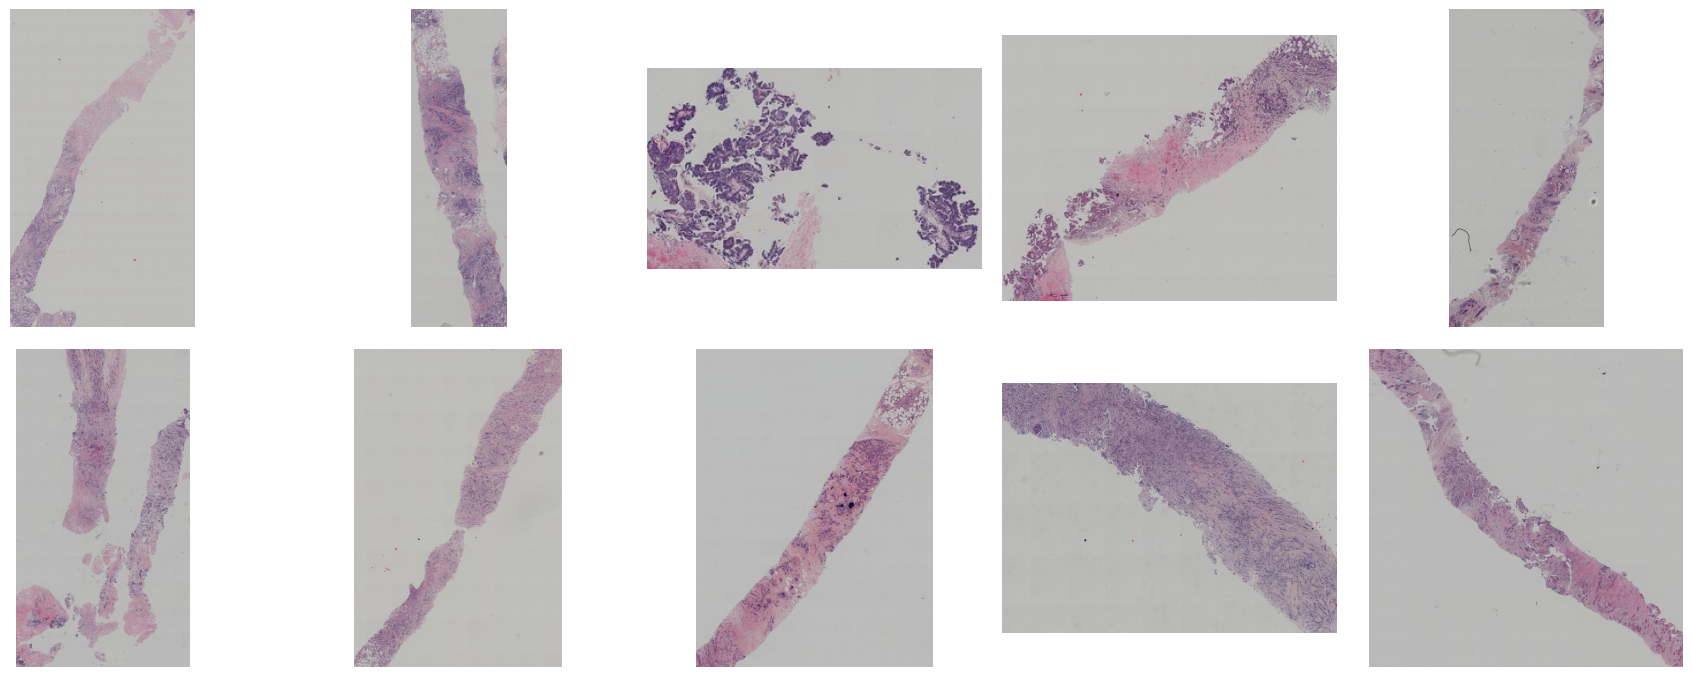

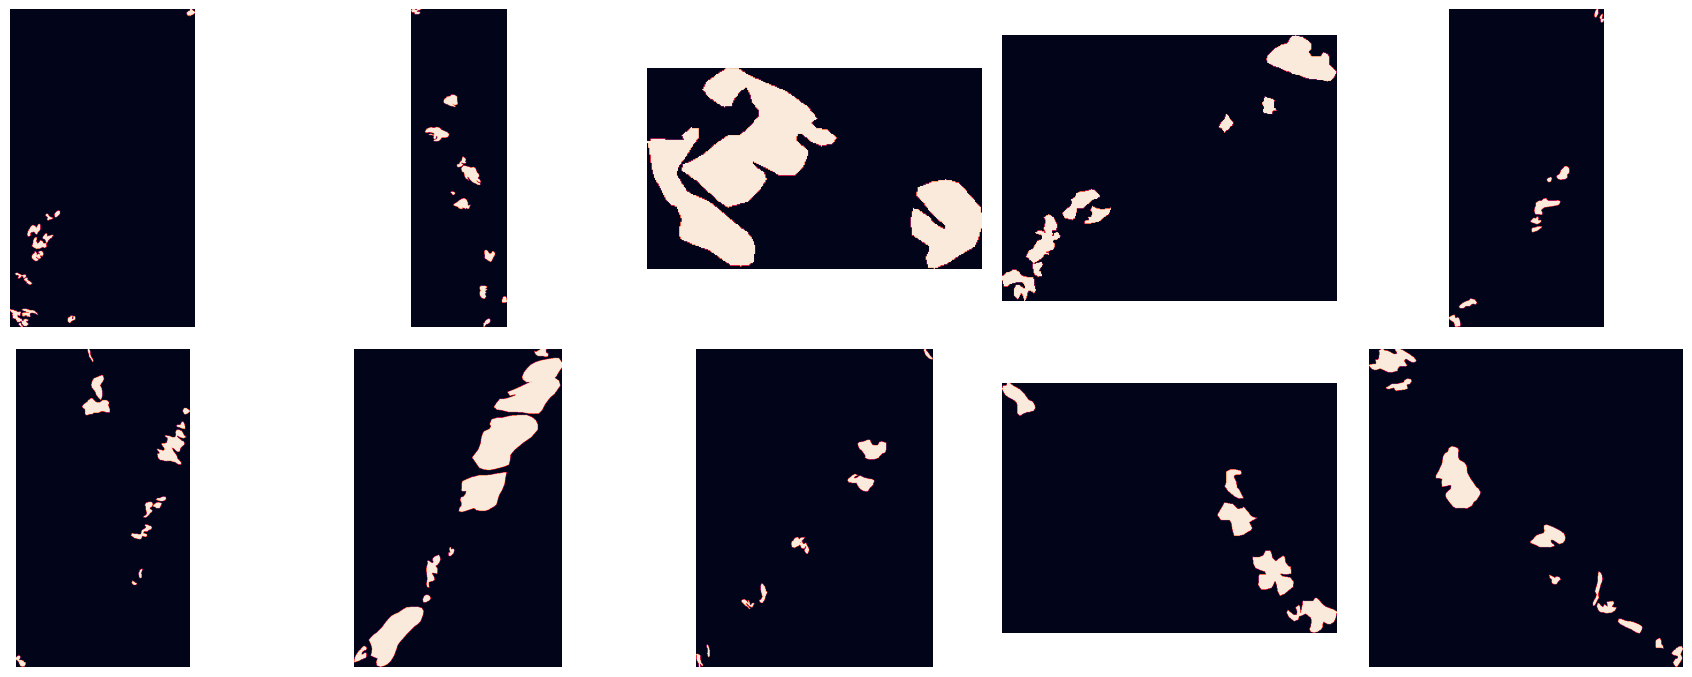

In [8]:
plot_10_images(data)
plot_10_images(masks)

In [9]:
patches = extract_patches_maskaware(data[10], masks[10], patch=96, n_patches=8)

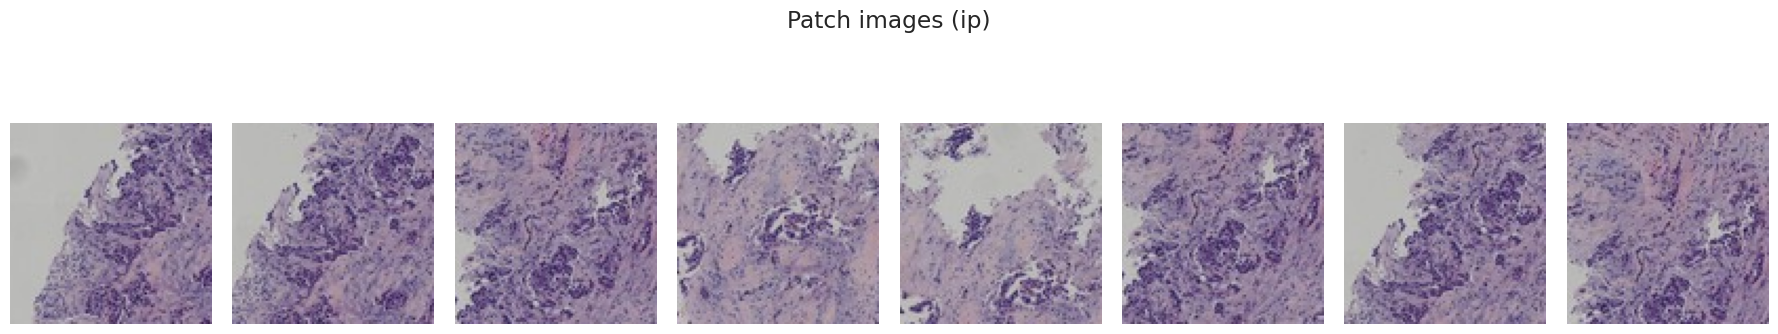

In [10]:
indices = list(range(8))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]
    plt.subplot(1, 8, i + 1)
    plt.imshow(ip)
    plt.axis("off")

plt.suptitle("Patch images (ip)")
plt.tight_layout()
plt.show()

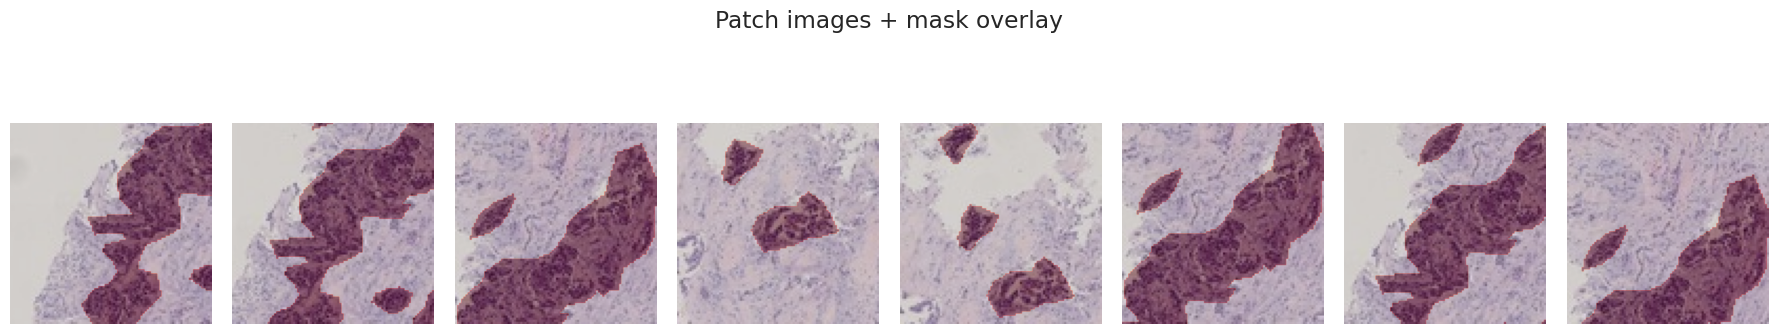

In [11]:
indices = list(range(8))

plt.figure(figsize=(18, 4))
for i, idx in enumerate(indices):
    ip, mp = patches[idx]
    plt.subplot(1, len(indices), i+1)
    plt.imshow(ip)
    plt.imshow(mp, cmap="Reds", alpha=0.35)
    plt.axis("off")

plt.suptitle("Patch images + mask overlay")
plt.tight_layout()
plt.show()

# Data preparation

In [12]:
labels = pd.read_csv("/kaggle/input/tissues-noshrek/an2dl2526c2v2/train_labels.csv")

labels_map = {
    "Triple negative": 0,
    "Luminal A": 1,
    "Luminal B": 2,
    "HER2(+)": 3
}

# Tieni solo le label delle immagini effettivamente caricate
labels = labels[labels["sample_index"].isin(file_names)].copy()

# RIORDINA le label nello STESSO ordine delle immagini
labels = labels.set_index("sample_index").loc[file_names].reset_index()

# Mappa stringa -> intero (shape: [N], dtype int)
y_train_val = labels["label"].map(labels_map).to_numpy()

In [13]:
# converti liste in array di indici per train_test_split
idx = np.arange(len(data))

idx_train, idx_val = train_test_split(
    idx, random_state=SEED, test_size=0.1, stratify=y_train_val
)

X_train = [data[i] for i in idx_train]
M_train = [masks[i] for i in idx_train]
y_train = y_train_val[idx_train]

X_val = [data[i] for i in idx_val]
M_val = [masks[i] for i in idx_val]
y_val = y_train_val[idx_val]

In [14]:
# Define the number of classes
num_classes = len(np.unique(y_train))

print("Number of Classes:", num_classes)

Number of Classes: 4


In [15]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{0: 62, 1: 142, 2: 183, 3: 135}


In [16]:
class_counts = torch.tensor(counts, dtype=torch.float32, device=device)
weights = 1.0 / class_counts
weights = weights / weights.sum()  # normalize

## Data Augmentation

In [17]:
mean = [0.0, 0.0, 0.0]
std  = [1.0, 1.0, 1.0]

train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=4),
    #transforms.ColorJitter(
    #    brightness=0.15,
    #    contrast=0.15,
    #    saturation=0.1,
    #    hue=0.02,
    #),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

In [18]:
class MILDataset(Dataset):
    def __init__(self, images, masks, labels=None, patch=96, n_patches=8,
                 transform_img=None, mode="train", seed=42):
        self.images = images
        self.masks = masks
        self.labels = labels
        self.patch = patch
        self.n_patches = n_patches
        self.transform_img = transform_img
        self.mode = mode
        self.seed = seed

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img  = self.images[idx]
        mask = self.masks[idx]

        # RNG: train random, val deterministic
        rng = np.random.default_rng(None if self.mode == "train" else (self.seed + idx))

        patches = extract_patches_maskaware(
            img, mask,
            patch=self.patch,
            n_patches=self.n_patches,
            rng=rng,                 
            min_mask_frac=0.01,      
            max_tries=50             
        )

        if len(patches) == 0:
            patches = [(img, mask)]  # fallback estremo

        if len(patches) < self.n_patches:
            idxs = rng.choice(len(patches), size=self.n_patches, replace=True)
            patches = [patches[i] for i in idxs]

        xb = []
        for ip, mp in patches:
            # NON fare ip[mp==0]=0
            if self.transform_img:
                ip = self.transform_img(ip)  # -> Tensor [3,H,W]
            else:
                ip = torch.from_numpy(ip).permute(2,0,1).float() / 255.0
            xb.append(ip)

        xb = torch.stack(xb, dim=0)  # [K,3,H,W]

        if self.labels is None:
            return xb
        y = int(self.labels[idx])
        return xb, y

In [19]:
batch_size = 4

In [20]:
train_dataset = MILDataset(X_train, M_train, y_train, patch=96, n_patches=16,
                           transform_img=train_transforms, mode="train", seed=SEED)
val_dataset   = MILDataset(X_val,   M_val,   y_val,   patch=96, n_patches=16,
                           transform_img=val_transforms, mode="val", seed=SEED)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

In [21]:
del X_train, M_train, X_val, M_val, y_train, y_val, data, masks, file_names
gc.collect()

69295

# Transfer learning: WideResNet50 

In [22]:
model = timm.create_model(
  model_name="hf-hub:1aurent/wide_resnet50_2.tiatoolbox-pcam",
  pretrained=True,
  num_classes=4,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [23]:
data_config = timm.data.resolve_model_data_config(model)
data_config

{'input_size': [3, 96, 96],
 'interpolation': 'bicubic',
 'mean': [0.0, 0.0, 0.0],
 'std': [1.0, 1.0, 1.0],
 'crop_pct': 1.0,
 'crop_mode': 'center'}

In [27]:
for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

In [28]:
criterion = nn.CrossEntropyLoss(weight=weights)  # weights già su device
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(
    params,
    lr=1e-3,
    weight_decay=1e-4
)
scaler = torch.cuda.amp.GradScaler() if device.type == "cuda" else None

In [29]:
if not os.path.exists("models"):
    os.makedirs("models")

In [30]:
def mil_pool(logits_bkc: torch.Tensor, method="mean"):
    """
    logits_bkc: [B, K, C]
    returns:    [B, C]
    """
    if method == "mean":
        return logits_bkc.mean(dim=1)
    if method == "max":
        return logits_bkc.max(dim=1).values
    raise ValueError(f"Unknown pooling method: {method}")

In [31]:
def train_one_epoch_mil(model, loader, criterion, optimizer, scaler, device,
                        pool_method="mean", f1_average="weighted"):
    model.train()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)                          # [B*K, C]
            logits = logits.view(B, K, -1)             # [B,K,C]
            logits_img = mil_pool(logits, method=pool_method)  # [B,C]
            loss = criterion(logits_img, y)

        if scaler is not None and device.type == "cuda":
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).detach().cpu().numpy())
        targs.append(y.detach().cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1


@torch.no_grad()
def validate_one_epoch_mil(model, loader, criterion, device,
                           pool_method="mean", f1_average="weighted"):
    model.eval()
    running_loss = 0.0
    preds, targs = [], []

    for xb, y in loader:
        xb = xb.to(device, non_blocking=True)
        y  = y.to(device, non_blocking=True)

        B, K, Cc, H, W = xb.shape
        x = xb.view(B*K, Cc, H, W)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x)
            logits = logits.view(B, K, -1)
            logits_img = mil_pool(logits, method=pool_method)
            loss = criterion(logits_img, y)

        running_loss += loss.item() * B

        preds.append(logits_img.argmax(dim=1).cpu().numpy())
        targs.append(y.cpu().numpy())

    y_true = np.concatenate(targs)
    y_pred = np.concatenate(preds)

    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(y_true, y_pred, average=f1_average, zero_division=0)

    return epoch_loss, epoch_f1


def fit_mil(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
            patience=10, mode="max", pool_method="mean", f1_average="weighted",
            experiment_name="mil", save_dir="models"):

    os.makedirs(save_dir, exist_ok=True)
    best_path = os.path.join(save_dir, f"{experiment_name}_model.pt")

    hist = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}

    best_metric = -1e9 if mode == "max" else 1e9
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, epochs + 1):
        tr_loss, tr_f1 = train_one_epoch_mil(
            model, train_loader, criterion, optimizer, scaler, device,
            pool_method=pool_method, f1_average=f1_average
        )
        va_loss, va_f1 = validate_one_epoch_mil(
            model, val_loader, criterion, device,
            pool_method=pool_method, f1_average=f1_average
        )

        hist["train_loss"].append(tr_loss)
        hist["val_loss"].append(va_loss)
        hist["train_f1"].append(tr_f1)
        hist["val_f1"].append(va_f1)

        print(f"Epoch {epoch:3d}/{epochs} | Train: {tr_loss:.4f} F1={tr_f1:.4f} | Val: {va_loss:.4f} F1={va_f1:.4f}")

        metric = va_f1
        improved = (metric > best_metric) if mode == "max" else (metric < best_metric)

        if improved:
            best_metric = metric
            best_epoch = epoch
            torch.save(model.state_dict(), best_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience > 0 and patience_counter >= patience:
                print(f"Early stopping @ epoch {epoch}")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    print(f"Restored best epoch {best_epoch} | best val_f1={best_metric:.4f}")

    return model, hist

In [32]:
%%time
mil_model, mil_hist = fit_mil(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=100,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=15,
    pool_method="mean",
    f1_average="weighted",         
    experiment_name="mil_resnet18"
)

best_val_f1 = max(mil_hist["val_f1"])
print(f"Best validation F1 ({'macro'}): {best_val_f1:.4f}")

Epoch   1/100 | Train: 1.3985 F1=0.2690 | Val: 1.4875 F1=0.2799
Epoch   2/100 | Train: 1.3852 F1=0.3044 | Val: 1.5232 F1=0.2370
Epoch   3/100 | Train: 1.3874 F1=0.2926 | Val: 1.3183 F1=0.2989
Epoch   4/100 | Train: 1.3827 F1=0.2845 | Val: 1.3162 F1=0.2451
Epoch   5/100 | Train: 1.3821 F1=0.2956 | Val: 1.3268 F1=0.3316
Epoch   6/100 | Train: 1.3822 F1=0.2582 | Val: 1.3249 F1=0.2500
Epoch   7/100 | Train: 1.3798 F1=0.3130 | Val: 1.3576 F1=0.2646
Epoch   8/100 | Train: 1.3802 F1=0.3235 | Val: 1.4009 F1=0.3473
Epoch   9/100 | Train: 1.3828 F1=0.2910 | Val: 1.4582 F1=0.2958
Epoch  10/100 | Train: 1.3784 F1=0.3130 | Val: 1.3435 F1=0.3180
Epoch  11/100 | Train: 1.3772 F1=0.3097 | Val: 1.3085 F1=0.2901
Epoch  12/100 | Train: 1.3799 F1=0.2989 | Val: 1.3196 F1=0.3418
Epoch  13/100 | Train: 1.3814 F1=0.3016 | Val: 1.3447 F1=0.2335
Epoch  14/100 | Train: 1.3811 F1=0.2818 | Val: 1.3303 F1=0.2647
Epoch  15/100 | Train: 1.3836 F1=0.2879 | Val: 1.3463 F1=0.3540
Epoch  16/100 | Train: 1.3668 F1=0.2978 

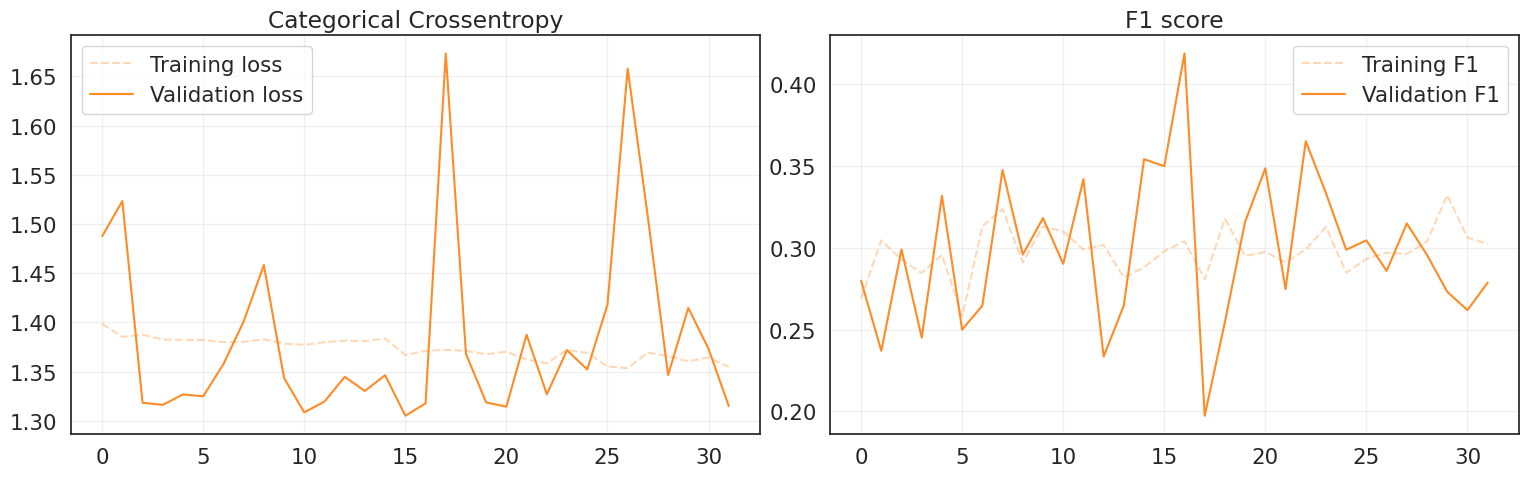

In [33]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(mil_hist['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(mil_hist['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(mil_hist['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(mil_hist['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

# Fine tuning

In [34]:
# --- Fine-tuning: unfreeze layer4 (+ classifier) and set per-group LRs ---

# 1) freeze everything
for p in mil_model.parameters():
    p.requires_grad = False

# 2) unfreeze classifier (final layer)
for p in mil_model.fc.parameters():      
    p.requires_grad = True

# 3) unfreeze last residual stage
for p in mil_model.layer4.parameters():
    p.requires_grad = True

# 4) optimizer with param groups (different LRs)
optimizer = torch.optim.AdamW(
    [
        {"params": mil_model.fc.parameters(),     "lr": 1e-4, "weight_decay": 1e-4},
        {"params": mil_model.layer4.parameters(), "lr": 1e-5, "weight_decay": 1e-4},
    ],
    betas=(0.9, 0.999),
    eps=1e-8,
)

In [35]:
%%time
# Fine-tune the model
ft_model, ft_history = fit_mil(
    model=mil_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=120,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    patience=15,
    pool_method="mean",
    experiment_name="mil_resnet50_ft"
)

final_val_acc = round(max(ft_history['val_f1']) * 100, 2)
print(f"Best validation F1 ({'weighted'}): {best_val_f1:.4f}")

Epoch   1/120 | Train: 1.3644 F1=0.2826 | Val: 1.3028 F1=0.3523
Epoch   2/120 | Train: 1.3529 F1=0.3085 | Val: 1.3077 F1=0.2923
Epoch   3/120 | Train: 1.3591 F1=0.3256 | Val: 1.3097 F1=0.3217
Epoch   4/120 | Train: 1.3541 F1=0.3434 | Val: 1.3134 F1=0.3159
Epoch   5/120 | Train: 1.3609 F1=0.2887 | Val: 1.3227 F1=0.3190
Epoch   6/120 | Train: 1.3540 F1=0.3247 | Val: 1.3061 F1=0.3149
Epoch   7/120 | Train: 1.3552 F1=0.3377 | Val: 1.3226 F1=0.3248
Epoch   8/120 | Train: 1.3493 F1=0.3271 | Val: 1.3151 F1=0.2806
Epoch   9/120 | Train: 1.3483 F1=0.3265 | Val: 1.3107 F1=0.3120
Epoch  10/120 | Train: 1.3593 F1=0.3062 | Val: 1.3146 F1=0.3280
Epoch  11/120 | Train: 1.3644 F1=0.3282 | Val: 1.3136 F1=0.2872
Epoch  12/120 | Train: 1.3419 F1=0.3293 | Val: 1.3242 F1=0.3499
Epoch  13/120 | Train: 1.3523 F1=0.3625 | Val: 1.3086 F1=0.2455
Epoch  14/120 | Train: 1.3460 F1=0.3646 | Val: 1.3130 F1=0.3465
Epoch  15/120 | Train: 1.3541 F1=0.3585 | Val: 1.3115 F1=0.2750
Epoch  16/120 | Train: 1.3550 F1=0.3010 

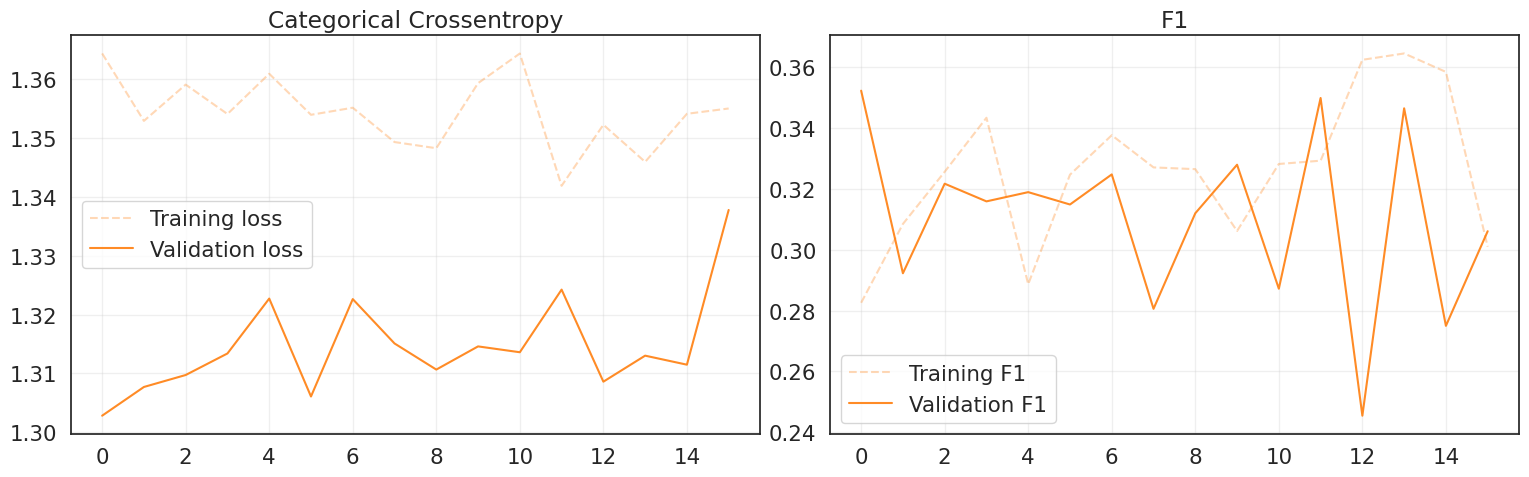

In [36]:
# @title Plot History
# Create a figure with two side-by-side subplots
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(ft_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(ft_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Categorical Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation Accuracy on the second axis
ax2.plot(ft_history['train_f1'], label='Training F1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(ft_history['val_f1'], label='Validation F1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

In [37]:
# Load the fine-tuned model for inference
best_model = ft_model

print("Model loaded successfully!")

Model loaded successfully!


In [38]:
test_data, test_masks, test_file_names = load_images_from_folder("/kaggle/input/tissues-noshrek/an2dl2526c2v2/test_data")
print(f"Loaded {len(test_data)} data")

Loaded 477 data


In [39]:
int_to_label = {
    0 : "Triple negative",
    1 : "Luminal A",
    2 : "Luminal B",
    3 : "HER2(+)"
}

def predict_one_image_mil(best_model, img, mask, patch=96, k=16, pool_method="mean"):
    best_model.eval()
    patches = extract_patches_maskaware(img, mask, patch=patch, n_patches=k)

    xb = []
    for ip, mp in patches:
        # DO NOT zero background unless you have evidence it helps.
        xb.append(val_transforms(ip))
    xb = torch.stack(xb).to(device)  # [K,3,H,W]

    with torch.no_grad(), torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
        logits = model(xb)               # [K,C]
        logits = logits.unsqueeze(0)     # [1,K,C]
        pooled = mil_pool(logits, method=pool_method).squeeze(0)  # [C]
        pred = pooled.argmax().item()
    return pred

# build submission
patch_size = 96  

sample_indices, predictions = [], []
for img, mask, fname in zip(test_data, test_masks, test_file_names):
    p = predict_one_image_mil(best_model, img, mask, patch=96, k=16, pool_method="mean")
    sample_indices.append(fname)
    predictions.append(int_to_label[int(p)])

submission_df = pd.DataFrame({
    'sample_index': sample_indices,
    'label': predictions
}).sort_values("sample_index").reset_index(drop=True)

os.makedirs("/kaggle/working/submissions", exist_ok=True)
submission_df.to_csv('/kaggle/working/submissions/mil_resnet50Patch2.csv', index=False)